In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROJECT_ROOT = '../../'

## Data Load

In [69]:
save_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', 'first_filtered_data.csv')
data_df = pd.read_csv(save_path)

media_42 = [
    # 온라인 활동(문21)
    "p__d14002","p__d14004","p__d14005","p__d14008","p__d14011", # 없어도 될 것 같다.

    # PC 활용(문22)
    "p__d25040","p__d25041","p__d25042","p__d25045","p__d25047","p__d25048","p__d25049",
    "p__d25052","p__d25053","p__d25056","p__d25057","p__d25058","p__d25060",

    # 스마트기기 활용(문23)
    "p__d25062","p__d25064","p__d25065","p__d25066","p__d25070","p__d25072","p__d25073",
    "p__d25076","p__d25077","p__d25080","p__d25081","p__d25082","p__d25083","p__d25085",

    # 프라이버시 침해 우려(문24)
    "p__d23003","p__d23005","p__d23006","p__d23007","p__d23008",

    # 미디어(문25)
    "p__n01038","p__n01041","p__n01042","p__n01043","p__n01047"
]
media_df = data_df[media_42]

In [70]:
pc_cols = ["p__d25040","p__d25041","p__d25042","p__d25045","p__d25047","p__d25048","p__d25049",
    "p__d25052","p__d25053","p__d25056","p__d25057","p__d25058","p__d25060"]
mobile_cols = ["p__d25062","p__d25064","p__d25065","p__d25066","p__d25070","p__d25072","p__d25073",
    "p__d25076","p__d25077","p__d25080","p__d25081","p__d25082","p__d25083","p__d25085"]
privacy_cols = ["p__d23003","p__d23005","p__d23006","p__d23007","p__d23008"]
media_literacy_cols = ["p__n01038","p__n01041","p__n01042","p__n01043","p__n01047"]

## Factor loading 및 score 계산

In [71]:
# 함수화
import statsmodels.multivariate.factor as sm_fa

def get_factor_scores(df, n_factor, rotation_method = 'oblimin', maxiter=1000):
    column_names = ['Factor' + str(i) for i in range(1, n_factor + 1)]

    fa = sm_fa.Factor(df, n_factor=n_factor, method='ml')
    fa_results = fa.fit(maxiter=maxiter)
    fa_results.rotate(rotation_method)

    #loading 계산
    loadings_values = fa_results.loadings
    # index는 분석에 쓴 원래 변수명들, columns는 요인 번호입니다.
    loadings_df = pd.DataFrame(
        loadings_values,
        columns=column_names,
        index=df.columns
    )

    #factor scores(실제로 사용할 값들)
    factor_scores = fa_results.factor_scoring(method = 'regression')
    scores_df = pd.DataFrame(factor_scores, columns=column_names)
    return loadings_df, scores_df

##  PC

In [51]:
X_pc = media_df[pc_cols].copy()
pc_loadings, pc_factors = get_factor_scores(X_pc, n_factor = 4)

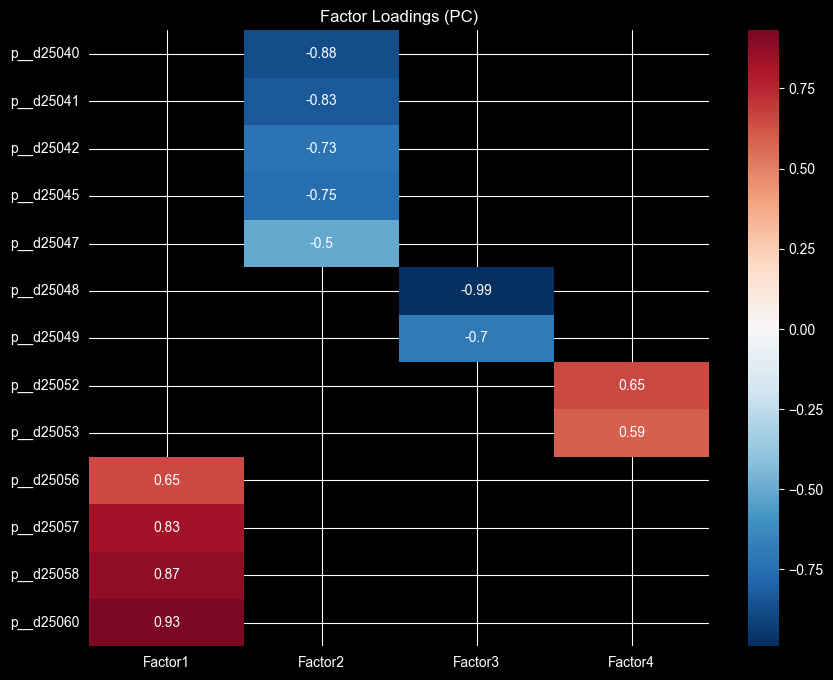

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(pc_loadings[pc_loadings.abs()>0.4], annot=True, cmap='RdBu_r', center=0, mask=0)
plt.title('Factor Loadings (PC)')
plt.show()

## Mobile

C:\Users\Playdata\miniconda3\envs\ai_basic_env\Lib\site-packages\statsmodels\multivariate\factor.py:417: UserWarning: Fitting did not converge
  warnings.warn("Fitting did not converge")


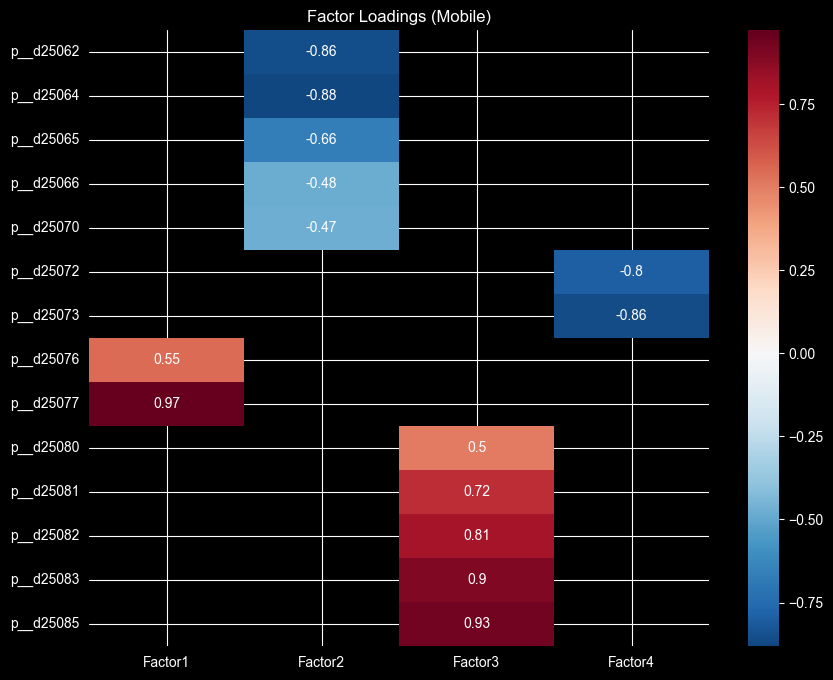

In [73]:
X_mobile = media_df[mobile_cols].copy()

mobile_loadings, mobile_factors = get_factor_scores(X_mobile, n_factor = 4)

plt.figure(figsize=(10, 8))
sns.heatmap(mobile_loadings[mobile_loadings.abs()>0.4], annot=True, cmap='RdBu_r', center=0, mask=0)
plt.title('Factor Loadings (Mobile)')
plt.show()

## Privacy

C:\Users\Playdata\miniconda3\envs\ai_basic_env\Lib\site-packages\statsmodels\multivariate\factor_rotation\_gpa_rotation.py:101: RuntimeWarning: divide by zero encountered in log10
  table.append([i_try, f, np.log10(s), al])


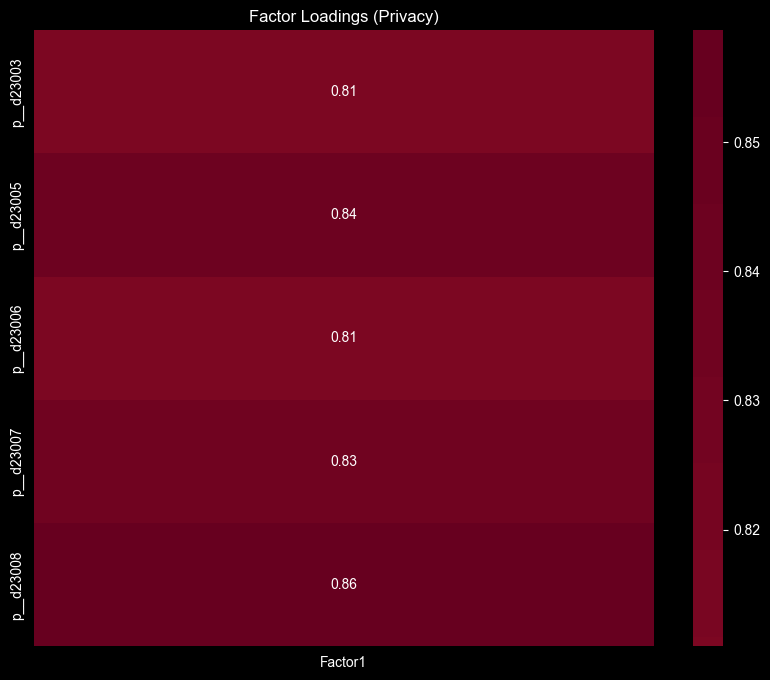

In [54]:
X_privacy = media_df[privacy_cols].copy()

privacy_loadings, privacy_factors = get_factor_scores(X_privacy, n_factor = 1)

plt.figure(figsize=(10, 8))
sns.heatmap(privacy_loadings[privacy_loadings.abs()>0.4], annot=True, cmap='RdBu_r', center=0, mask=0)
plt.title('Factor Loadings (Privacy)')
plt.show()

## Media Literacy


C:\Users\Playdata\miniconda3\envs\ai_basic_env\Lib\site-packages\statsmodels\multivariate\factor_rotation\_gpa_rotation.py:101: RuntimeWarning: divide by zero encountered in log10
  table.append([i_try, f, np.log10(s), al])


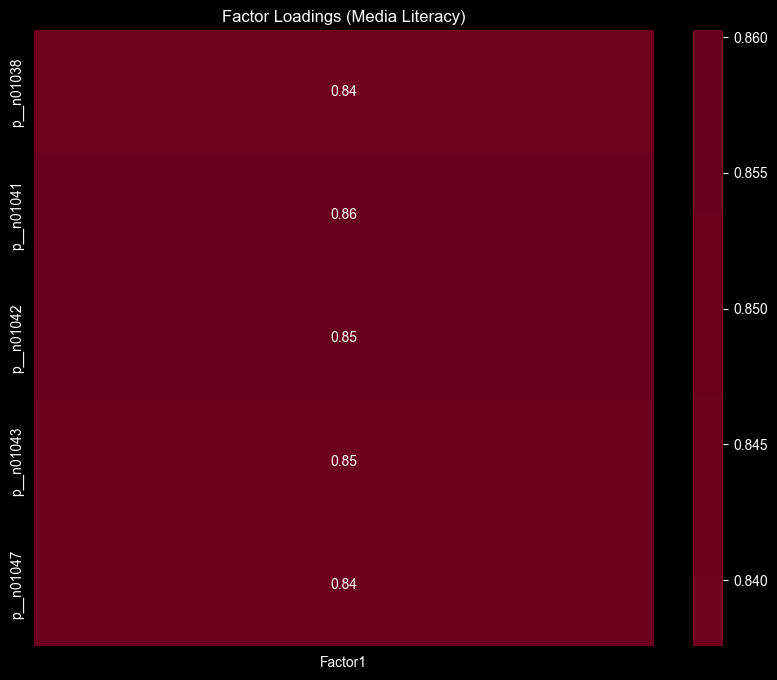

In [55]:
X_media_literacy = media_df[media_literacy_cols].copy()

media_literacy_loadings, media_literacy_factors = get_factor_scores(X_media_literacy, n_factor = 1)

plt.figure(figsize=(10, 8))
sns.heatmap(media_literacy_loadings[media_literacy_loadings.abs()>0.4], annot=True, cmap='RdBu_r', center=0, mask=0)
plt.title('Factor Loadings (Media Literacy)')
plt.show()

## 신기술?

In [40]:
csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', 'selected_data_2023.csv')
all_2023_df = pd.read_csv(csv_path, low_memory=False)

hightech_cols = ['p__k020'+str(i).zfill(2) for i in range(1,15)]

hightech_df = all_2023_df[hightech_cols].copy()

In [42]:
from scipy.stats import chi2

def bartlett_sphericity_test(df):
    n, k = df.shape
    corr_matrix = df.corr()
    determinant = np.linalg.det(corr_matrix)

    # 행렬식이 0에 너무 가까우면 로그 계산 시 문제가 생길 수 있음
    if determinant <= 0:
        return np.nan, np.nan, np.nan

    statistic = - (n - 1 - (2 * k + 5) / 6) * np.log(determinant)
    degrees_of_freedom = k * (k - 1) / 2
    p_value = chi2.sf(statistic, degrees_of_freedom)

    return statistic, p_value, degrees_of_freedom

# 사용 예시
stat, p, df_degree = bartlett_sphericity_test(hightech_df)
print(f"Bartlett's Test - Chi-square: {stat:.4f}, df: {df_degree}, p-value: {p}")

Bartlett's Test - Chi-square: 17489.5408, df: 91.0, p-value: 0.0


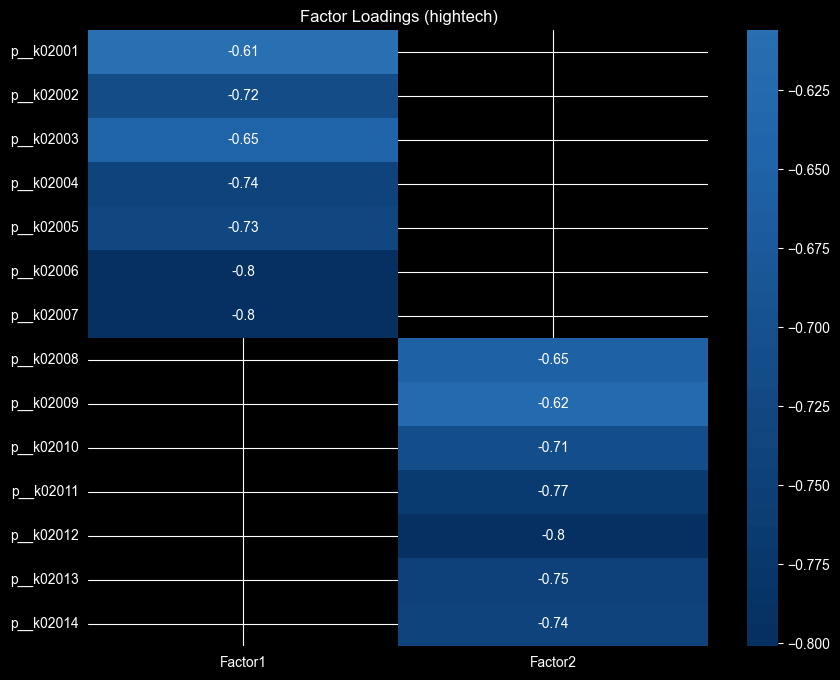

In [56]:
hightech_loadings, hightech_factors = get_factor_scores(hightech_df, n_factor = 2)

plt.figure(figsize=(10, 8))
sns.heatmap(hightech_loadings[hightech_loadings.abs()>0.4], annot=True, cmap='RdBu_r', center=0, mask=0)
plt.title('Factor Loadings (hightech)')
plt.show()

In [43]:
import pandas as pd
import numpy as np

def cronbach_alpha(df):
    # 문항 개수 (K)
    k = df.shape[1]

    # 각 문항의 분산 합계
    sum_of_item_variances = df.var(ddof=1).sum()

    # 전체 문항 합계의 분산
    total_score_variance = df.sum(axis=1).var(ddof=1)

    # 공식 적용
    alpha = (k / (k - 1)) * (1 - (sum_of_item_variances / total_score_variance))
    return alpha

# 예시 데이터 (설문조사 응답 5점 척도)


print(f"Cronbach's Alpha: {cronbach_alpha(hightech_df):.4f}")

Cronbach's Alpha: 0.9085


In [62]:
from scipy import stats

def get_factor_correlation(pca_data, target_series):
    """
    PCA 성분들과 이탈 여부(is_churned) 사이의 점이분 상관계수를 계산하고 시각화합니다.
    """
    pc_names = ['Factor'+str(i) for i in range(1, pca_data.shape[1]+1)]
    # 1. 분석용 데이터프레임 병합
    df_corr = pd.DataFrame(pca_data, columns=pc_names)
    df_corr['target'] = target_series.values

    results = []

    # 2. 각 주성분별 상관계수 계산
    print(f"🚀 [EFA Components vs is_churned] 상관분석 시작\n")
    for pc in pc_names:
        # 결측치 제거 후 계산
        temp_df = df_corr[[pc, 'target']].dropna()
        r_pb, p_val = stats.pointbiserialr(temp_df['target'], temp_df[pc])

        results.append({
            'Component': pc,
            'Correlation': r_pb,
            'p-value': p_val
        })

        # 결과 요약 출력
        status = "✅ 유의미" if p_val < 0.05 else "❌ 미흡"
        print(f"  - {pc}: Corr = {r_pb:.4f}, p-val = {p_val:.4e} ({status})")

    # 3. 결과 데이터프레임 정리
    result_df = pd.DataFrame(results).sort_values(by='Correlation', key=abs, ascending=False)

    # 4. 시각화 (Optional)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Correlation', y='Component', data=result_df, hue='Component', palette='vlag')
    plt.axvline(0, color='black', linestyle='-', linewidth=1)
    plt.title("Correlation: PCA Components vs is_churned")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    return result_df

🚀 [EFA Components vs is_churned] 상관분석 시작

  - Factor1: Corr = 0.1127, p-val = 6.7890e-08 (✅ 유의미)
  - Factor2: Corr = 0.0607, p-val = 3.7412e-03 (✅ 유의미)


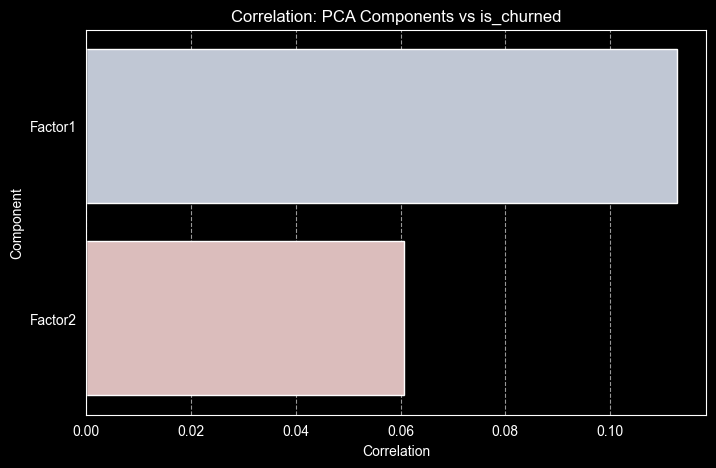

,Component,Correlation,p-value
0,Factor1,0.112722,6.789012e-08
1,Factor2,0.060694,3.741157e-03


In [63]:
get_factor_correlation(hightech_factors, all_2023_df['is_churned'])

🚀 [EFA Components vs is_churned] 상관분석 시작

  - Factor1: Corr = -0.1109, p-val = 1.1004e-07 (✅ 유의미)
  - Factor2: Corr = 0.0773, p-val = 2.1976e-04 (✅ 유의미)
  - Factor3: Corr = 0.0858, p-val = 4.1082e-05 (✅ 유의미)
  - Factor4: Corr = -0.0834, p-val = 6.6801e-05 (✅ 유의미)


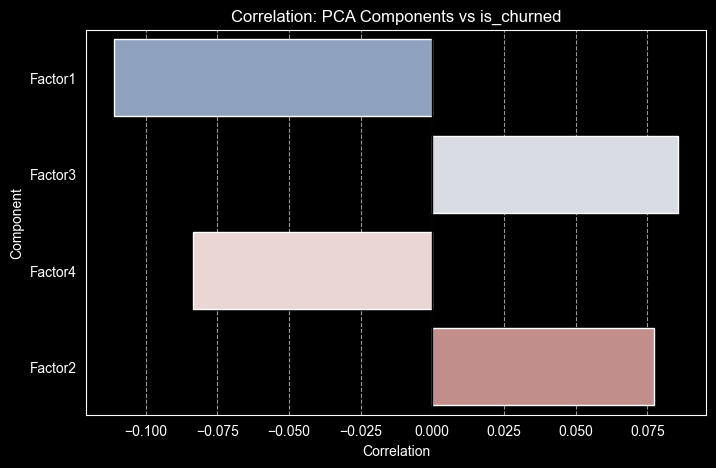

,Component,Correlation,p-value
0,Factor1,-0.110909,1.100378e-07
2,Factor3,0.085781,4.108168e-05
3,Factor4,-0.083407,6.680142e-05
1,Factor2,0.077313,2.197623e-04


In [64]:
get_factor_correlation(pc_factors, all_2023_df['is_churned'])

🚀 [EFA Components vs is_churned] 상관분석 시작

  - Factor1: Corr = -0.0920, p-val = 1.0756e-05 (✅ 유의미)
  - Factor2: Corr = -0.0115, p-val = 5.8402e-01 (❌ 미흡)
  - Factor3: Corr = -0.1059, p-val = 4.0055e-07 (✅ 유의미)
  - Factor4: Corr = 0.0355, p-val = 9.0566e-02 (❌ 미흡)


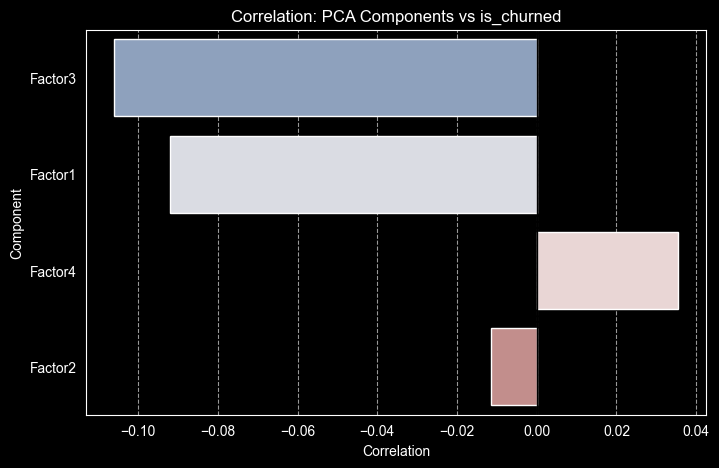

,Component,Correlation,p-value
2,Factor3,-0.105912,4.005485e-07
0,Factor1,-0.092032,1.075630e-05
3,Factor4,0.035452,9.056563e-02
1,Factor2,-0.011472,5.840228e-01


In [65]:
get_factor_correlation(mobile_factors, all_2023_df['is_churned'])

🚀 [EFA Components vs is_churned] 상관분석 시작

  - Factor1: Corr = -0.1235, p-val = 3.2678e-09 (✅ 유의미)


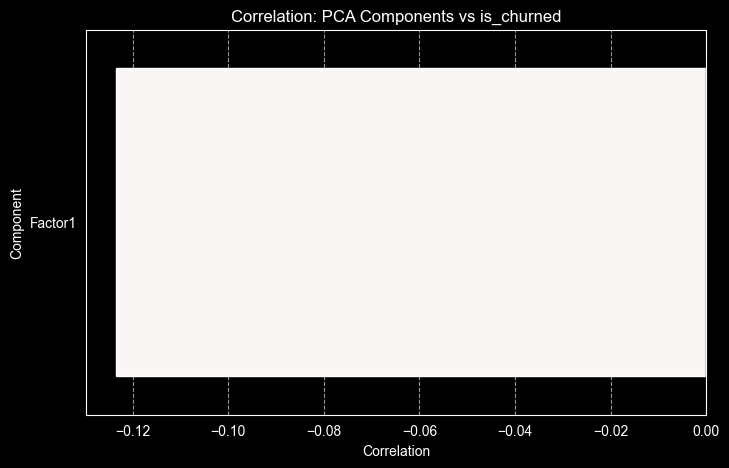

,Component,Correlation,p-value
0,Factor1,-0.123522,3.267757e-09


In [66]:
get_factor_correlation(privacy_factors, all_2023_df['is_churned'])

🚀 [EFA Components vs is_churned] 상관분석 시작

  - Factor1: Corr = -0.1483, p-val = 1.1175e-12 (✅ 유의미)


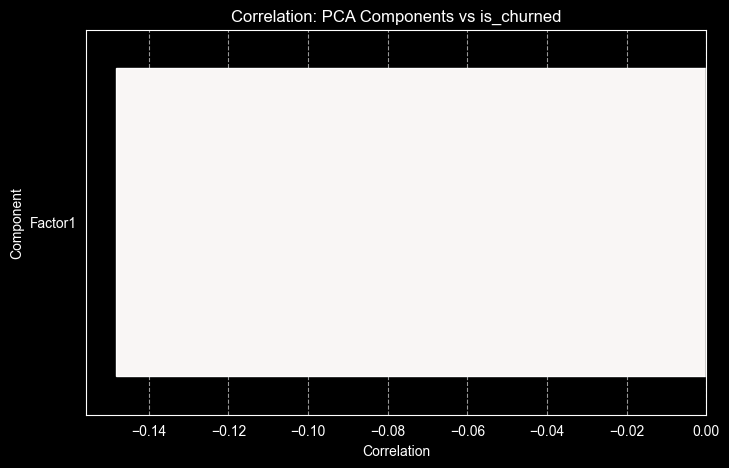

,Component,Correlation,p-value
0,Factor1,-0.148269,1.117474e-12


In [67]:
get_factor_correlation(media_literacy_factors, all_2023_df['is_churned'])